<a href="https://colab.research.google.com/github/silvia-dev-prog/ai-agents-for-beginners/blob/main/silviamoraes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df=pd.read_csv('/content/banana_quality.csv', sep=',', encoding='latin-1')
df.head()


,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
0,-1.924968,0.468078,3.077832,-1.472177,0.294799,2.435570,0.271290,Good
1,-2.409751,0.486870,0.346921,-2.495099,-0.892213,2.067549,0.307325,Good
2,-0.357607,1.483176,1.568452,-2.645145,-0.647267,3.090643,1.427322,Good
3,-0.868524,1.566201,1.889605,-1.273761,-1.006278,1.873001,0.477862,Good
4,0.651825,1.319199,-0.022459,-1.209709,-1.430692,1.078345,2.812442,Good


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define features (X) and target (y)
X = df.drop('Quality', axis=1)
y = df['Quality']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression(solver='lbfgs', max_iter=10000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of Logistic Regression: {accuracy:.4f}')

Accuracy of Logistic Regression: 0.8794


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Drop the 'Quality' column as it's no longer the target and not a feature for 'Acidity' prediction
df_linear_reg = df.drop('Quality', axis=1)

# Define features (X) and target (y) for linear regression
X_lr = df_linear_reg.drop('Acidity', axis=1)
y_lr = df_linear_reg['Acidity']

# Split the data into training and testing sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_lr, y_train_lr)

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test_lr)

# Calculate and print the R-squared coefficient
r2 = r2_score(y_test_lr, y_pred_lr)
print(f'R-squared coefficient for Linear Regression (predicting Acidity): {r2:.4f}')

R-squared coefficient for Linear Regression (predicting Acidity): 0.3326


#q 7

In [14]:
df=pd.read_csv('/content/Cota_Parlamentar_2024.csv')
df

,NomeParlamentar,UF,Partido,Descricao,Mes,Valor
0,Danilo Forte,CE,UNIÃO,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,6.0,95.53
1,Danilo Forte,CE,UNIÃO,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7.0,97.47
2,Danilo Forte,CE,UNIÃO,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,8.0,95.53
3,Danilo Forte,CE,UNIÃO,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,9.0,104.58
4,Danilo Forte,CE,UNIÃO,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,10.0,104.58
...,...,...,...,...,...,...
230856,Tadeu Oliveira,CE,PL,PASSAGEM AÉREA - SIGEPA,12.0,75.00
230857,Tadeu Oliveira,CE,PL,PASSAGEM AÉREA - SIGEPA,12.0,1492.57
230858,Tadeu Oliveira,CE,PL,PASSAGEM AÉREA - SIGEPA,12.0,100.00
230859,Tadeu Oliveira,CE,PL,PASSAGEM AÉREA - SIGEPA,12.0,1469.95


In [15]:
df.isna().sum()

,0
NomeParlamentar,0
UF,29662
Partido,29662
Descricao,29662
Mes,29662
Valor,29714


In [16]:
total_missing = df.isnull().sum().sum()
total_elements = df.size
percentage_missing = (total_missing / total_elements) * 100
print(f"Percentual total de dados faltantes: {percentage_missing:.2f}%")

Percentual total de dados faltantes: 10.71%


In [17]:
df.isna().sum()

,0
NomeParlamentar,0
UF,29662
Partido,29662
Descricao,29662
Mes,29662
Valor,29714


In [11]:
total_missing = df.isnull().sum().sum()
total_elements = df.size
percentage_missing = (total_missing / total_elements) * 100
print(f"Percentual total de dados faltantes: {percentage_missing:.2f}%")

Percentual total de dados faltantes: 0.00%


In [27]:
partido_maior_valor = df.groupby('Partido')['Valor'].sum().idxmax()
maior_valor = df.groupby('Partido')['Valor'].sum().max()
print(f"O partido com o maior valor total é o {partido_maior_valor} com um valor de {maior_valor:.2f}")

O partido com o maior valor total é o PL com um valor de 42055423.52


In [19]:
partidos_e_valores = df.groupby('Partido')['Valor'].sum().sort_values(ascending=False)
print("Valores totais por Partido:\n")
print(partidos_e_valores.apply(lambda x: f'{x:.2f}'))

Valores totais por Partido:

Partido
PL               42055423.52
PT               33613717.20
UNIÃO            29518588.03
PP               24318600.26
PSD              23470452.40
REPUBLICANOS     22301293.75
MDB              20666701.39
PDT               9083063.85
PSB               7408425.20
PSDB              6736727.03
PODE              6084443.01
PSOL              5868667.73
AVANTE            3747030.37
PCdoB             3550459.63
SOLIDARIEDADE     2488446.18
PRD               2363678.89
PV                2012046.24
NOVO              1485222.77
CIDADANIA         1180368.17
REDE               427668.81
S.PART.             24423.63
Name: Valor, dtype: object


In [20]:
descricao_maior_valor = df.groupby('Descricao')['Valor'].sum().idxmax()
maior_valor_descricao = df.groupby('Descricao')['Valor'].sum().max()
print(f"A descrição com o maior valor total é '{descricao_maior_valor}' com um valor de {maior_valor_descricao:.2f}")

A descrição com o maior valor total é 'DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.' com um valor de 100317004.98


In [28]:
descricao_e_valores = df.groupby('Descricao')['Valor'].sum().sort_values(ascending=False)
print("Valores totais por Descrição:\n")
print(descricao_e_valores.apply(lambda x: f'{x:.2f}'))

Valores totais por Descrição:

Descricao
DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.                         100317004.98
LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES                 42791291.12
PASSAGEM AÉREA - SIGEPA                                       40127599.48
MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR     32704643.63
COMBUSTÍVEIS E LUBRIFICANTES.                                 22399043.52
TELEFONIA                                                      3145320.79
LOCAÇÃO OU FRETAMENTO DE AERONAVES                             2154396.60
SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA.       1593439.59
PASSAGEM AÉREA - REEMBOLSO                                     1147554.86
PASSAGEM AÉREA - RPA                                           1010078.73
FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR                      691941.12
LOCAÇÃO OU FRETAMENTO DE EMBARCAÇÕES                            237650.00
ASSINATURA DE PUBLICAÇÕES                                        70785.

In [21]:
grouped_by_month = df.groupby('Mes')['Valor']

q1 = grouped_by_month.quantile(0.25)
q3 = grouped_by_month.quantile(0.75)
iqr = q3 - q1

print("Q1 per Mes:\n", q1.head())
print("\nQ3 per Mes:\n", q3.head())
print("\nIQR per Mes:\n", iqr.head())

Q1 per Mes:
 Mes
1.0    149.595
2.0    119.460
3.0    125.380
4.0    120.530
5.0    119.890
Name: Valor, dtype: float64

Q3 per Mes:
 Mes
1.0    1380.0900
2.0    1172.0700
3.0    1352.6400
4.0    1252.5800
5.0    1305.1825
Name: Valor, dtype: float64

IQR per Mes:
 Mes
1.0    1230.4950
2.0    1052.6100
3.0    1227.2600
4.0    1132.0500
5.0    1185.2925
Name: Valor, dtype: float64


**Reasoning**:
Now that Q1, Q3, and IQR have been calculated for each month, the next step is to determine the upper and lower bounds for outlier detection using the 1.5*IQR rule and then identify all 'Valor' data points that fall outside these bounds for each respective month.



In [22]:
outliers = pd.DataFrame()

for mes in df['Mes'].unique():
    if pd.isna(mes):
        continue

    month_df = df[df['Mes'] == mes]

    # Get the calculated Q1, Q3, and IQR for the current month
    q1_mes = q1.loc[mes]
    q3_mes = q3.loc[mes]
    iqr_mes = iqr.loc[mes]

    # Calculate outlier bounds for the current month
    lower_bound = q1_mes - 1.5 * iqr_mes
    upper_bound = q3_mes + 1.5 * iqr_mes

    # Identify outliers for the current month
    month_outliers = month_df[(month_df['Valor'] < lower_bound) | (month_df['Valor'] > upper_bound)]

    # Add the month column to the identified outliers for clarity
    month_outliers['Mes_Outlier'] = mes

    # Concatenate to the overall outliers DataFrame
    outliers = pd.concat([outliers, month_outliers])

print(f"Total number of outliers identified: {len(outliers)}")
print("First 5 outliers identified:\n", outliers.head())

Total number of outliers identified: 22681
First 5 outliers identified:
     NomeParlamentar  UF Partido  \
48     Danilo Forte  CE   UNIÃO   
60     Danilo Forte  CE   UNIÃO   
271    Danilo Forte  CE   UNIÃO   
310    Danilo Forte  CE   UNIÃO   
470    Danilo Forte  CE   UNIÃO   

                                             Descricao  Mes    Valor  \
48   MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...  6.0  6500.00   
60   MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...  6.0  3386.84   
271               DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.  6.0  8369.69   
310               DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.  6.0  7000.00   
470      LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES  6.0  6271.00   

     Mes_Outlier  
48           6.0  
60           6.0  
271          6.0  
310          6.0  
470          6.0  


/tmp/ipython-input-2400043947.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  month_outliers['Mes_Outlier'] = mes
/tmp/ipython-input-2400043947.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  month_outliers['Mes_Outlier'] = mes
/tmp/ipython-input-2400043947.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

**Reasoning**:
The previous code generated `SettingWithCopyWarning` because it was attempting to modify a slice of a DataFrame. To fix this, I will explicitly create a copy of the filtered `month_outliers` DataFrame to prevent this warning and ensure proper assignment of the `Mes_Outlier` column.



In [23]:
outliers = pd.DataFrame()

for mes in df['Mes'].unique():
    if pd.isna(mes):
        continue

    month_df = df[df['Mes'] == mes]

    # Get the calculated Q1, Q3, and IQR for the current month
    q1_mes = q1.loc[mes]
    q3_mes = q3.loc[mes]
    iqr_mes = iqr.loc[mes]

    # Calculate outlier bounds for the current month
    lower_bound = q1_mes - 1.5 * iqr_mes
    upper_bound = q3_mes + 1.5 * iqr_mes

    # Identify outliers for the current month and create a copy to avoid SettingWithCopyWarning
    month_outliers = month_df[(month_df['Valor'] < lower_bound) | (month_df['Valor'] > upper_bound)].copy()

    # Add the month column to the identified outliers for clarity
    month_outliers['Mes_Outlier'] = mes

    # Concatenate to the overall outliers DataFrame
    outliers = pd.concat([outliers, month_outliers])

print(f"Total number of outliers identified: {len(outliers)}")
print("First 5 outliers identified:\n", outliers.head())

Total number of outliers identified: 22681
First 5 outliers identified:
     NomeParlamentar  UF Partido  \
48     Danilo Forte  CE   UNIÃO   
60     Danilo Forte  CE   UNIÃO   
271    Danilo Forte  CE   UNIÃO   
310    Danilo Forte  CE   UNIÃO   
470    Danilo Forte  CE   UNIÃO   

                                             Descricao  Mes    Valor  \
48   MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...  6.0  6500.00   
60   MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...  6.0  3386.84   
271               DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.  6.0  8369.69   
310               DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.  6.0  7000.00   
470      LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES  6.0  6271.00   

     Mes_Outlier  
48           6.0  
60           6.0  
271          6.0  
310          6.0  
470          6.0  


**Reasoning**:
Now that the outliers have been identified for each month, the next step is to generate a box plot to visually represent the distribution of 'Valor' per 'Mes' and highlight these outliers. This will fulfill the second part of the main task's visualization requirement.



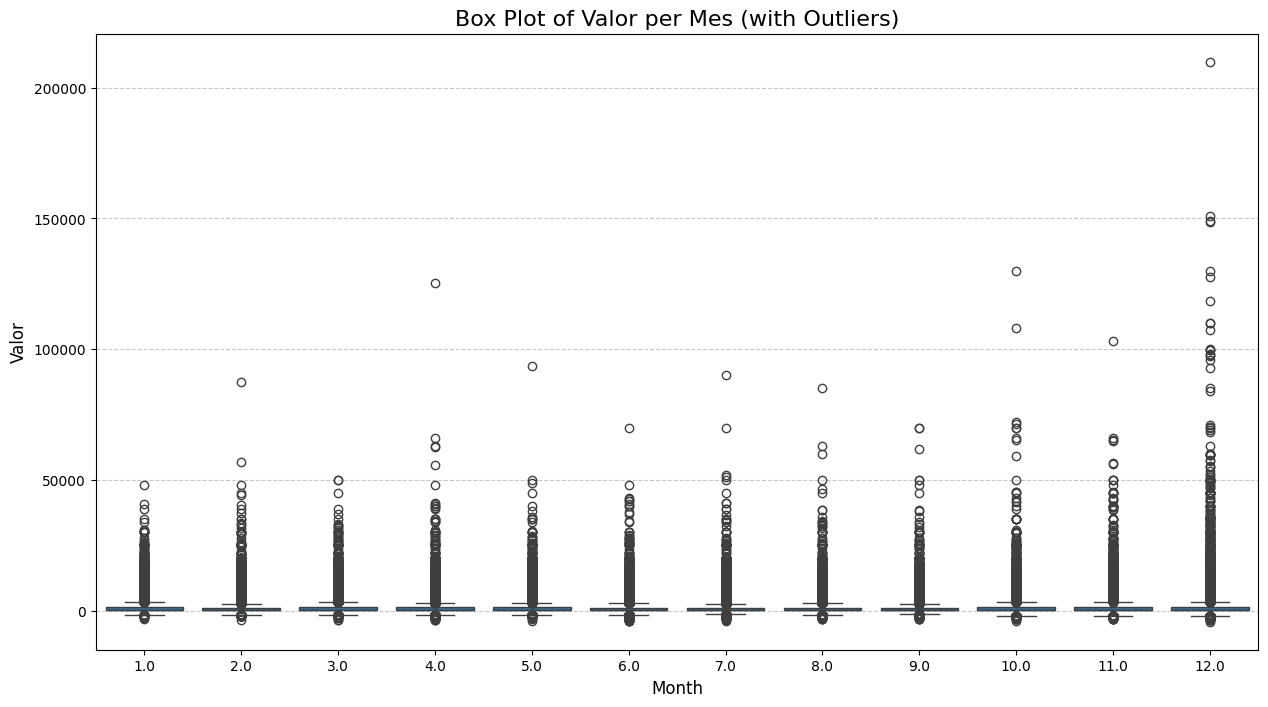

In [24]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='Mes', y='Valor', data=df)
plt.title('Box Plot of Valor per Mes (with Outliers)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [25]:
months_with_outliers = outliers['Mes_Outlier'].unique()
months_with_outliers_sorted = sorted(months_with_outliers)

print(f"Months identified with outliers: {months_with_outliers_sorted}")

Months identified with outliers: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0)]


In [26]:
outliers_per_month_count = outliers['Mes_Outlier'].value_counts()

month_with_most_outliers = outliers_per_month_count.idxmax()
max_outlier_count = outliers_per_month_count.max()

print(f"O mês com o maior número de outliers é o {int(month_with_most_outliers)} com {max_outlier_count} outliers.")

O mês com o maior número de outliers é o 7 com 2367 outliers.
